In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
mnist = np.genfromtxt('data/MNIST_Shortened.csv', delimiter=',')
X = mnist[1:, 0:784]
y = mnist[1:, -1]
print(X.shape, y.shape)

(6000, 784) (6000,)


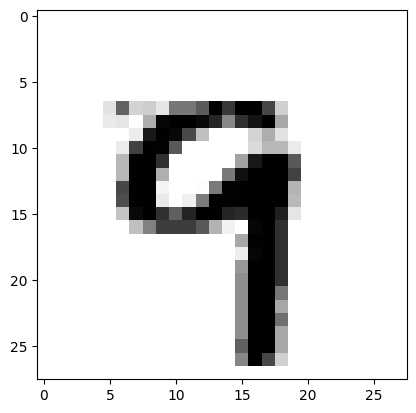

In [3]:
plt.imshow(X[0].reshape(28, 28), cmap='gray_r')
plt.show()

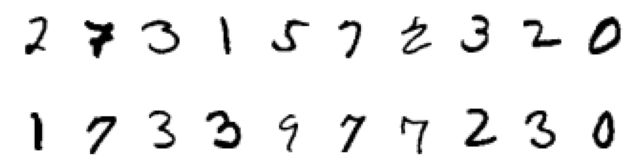

In [18]:
plt.figure(figsize=(8, 12))
for i in range(20):
    plt.subplot(10,10,i+1)
    plt.imshow(X[np.random.randint(0,6000)].reshape(28,28),cmap='gray_r')
    plt.axis('off')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)
X_train.shape

(4200, 784)

## Filter Method: Variance Threshold to remove low or no variance features

In [6]:
from sklearn.feature_selection import VarianceThreshold

variance_selector = VarianceThreshold(threshold=0)

X_train_fs = variance_selector.fit_transform(X_train)
X_test_fs = variance_selector.transform(X_test)

print(f"""
{X_train.shape[1]-X_train_fs.shape[1]} features have been removed,
{X_train_fs.shape[1]} features remain""")


124 features have been removed,
660 features remain


In [7]:
X_train.shape

(4200, 784)

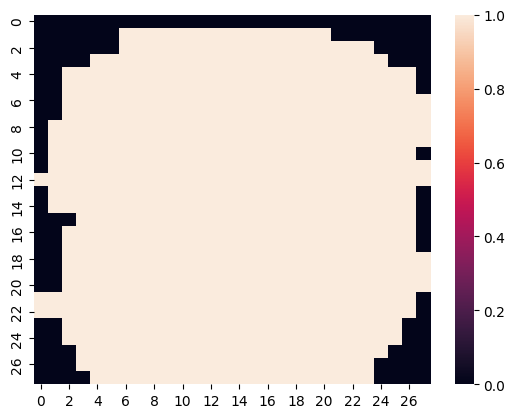

In [8]:
selected_features = variance_selector.get_support()
selected_features = selected_features.reshape(28, 28)

sns.heatmap(selected_features, cmap='rocket')
plt.show()

## Filter Method: SelectKBest

In [9]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=200)

X_train_fs = selector.fit_transform(X_train_fs, y_train)
X_test_fs = selector.transform(X_test_fs)

In [12]:
new_features_indices = variance_selector.get_support(indices=True)[selector.get_support()]
new_features_boolean = np.isin(np.arange(784), new_features_indices)
print(new_features_boolean.shape, new_features_indices.shape)

(784,) (200,)


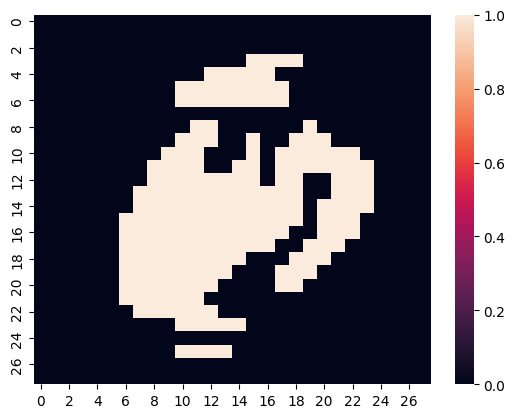

In [13]:
sns.heatmap(new_features_boolean.reshape(28, 28), cmap='rocket')
plt.show()

## IV: Wrapper Method - Recursive Feature Elimination using RFECV

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_selection import RFECV

In [21]:
scaler = StandardScaler()
X_train_fs = scaler.fit_transform(X_train_fs)
X_test_fs = scaler.transform(X_test_fs)

In [24]:
rf = RandomForestClassifier(random_state=0)
rfecv = RFECV(rf, cv=3, step=5)

X_train_fs = rfecv.fit_transform(X_train_fs, y_train)
X_test_fs = rfecv.transform(X_test_fs)

print(f"Number of remaining features: {X_train_fs.shape[1]}")

Number of remaining features: 180


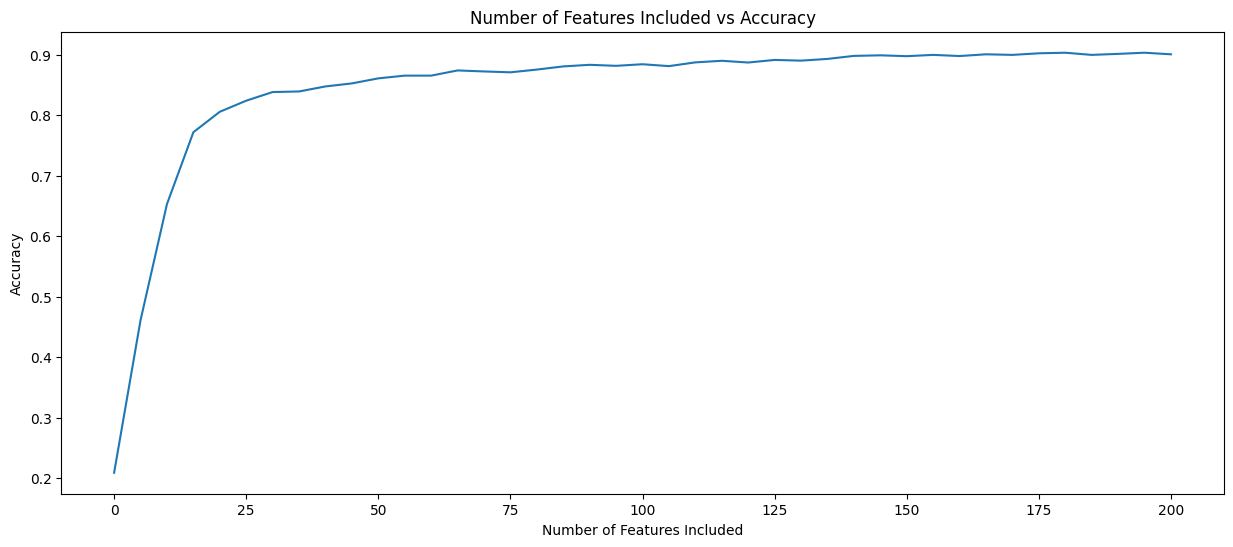

In [25]:
plt.figure(figsize=(15, 6))
plt.title("Number of Features Included vs Accuracy")
plt.xlabel("Number of Features Included")
plt.ylabel("Accuracy")
plt.plot(np.linspace(0, 200, 41), rfecv.cv_results_['mean_test_score'])
plt.show()

## V: Training and Evaluating a Model

In [26]:
rf_selected_features = RandomForestClassifier()
rf_selected_features.fit(X_train_fs, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred = rf_selected_features.predict(X_test_fs)
print(f"Accuracy Score: {accuracy_score(y_test,y_pred)*100:.2f}%")

Accuracy Score: 92.00%


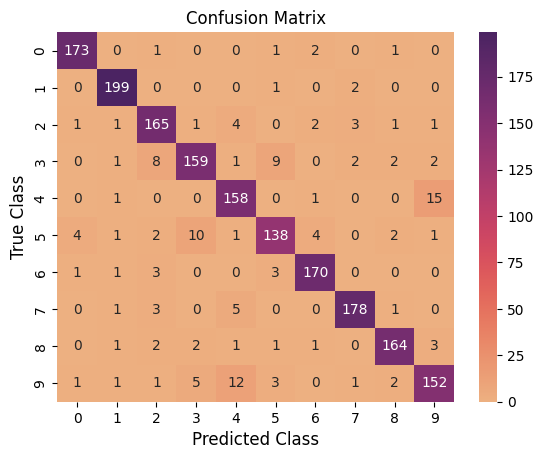

In [28]:
cm = confusion_matrix(y_test, y_pred)
ax = sns.heatmap(cm, cmap='flare', annot=True, fmt='d')

plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.title('Confusion Matrix', fontsize=12)
plt.show()

## VI: Addressing Class Imbalance